In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from xgboost import XGBRegressor

In [88]:
df = pd.read_csv("Solar Energy.csv", dtype={'Zip': str}, low_memory=False)
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(218115, 17)


,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


In [89]:
df = df.drop(columns=[
    'Project ID',
    'Circuit ID',
    'Data Through Date'
], errors='ignore')

In [90]:
df['Zip'] = df['Zip'].astype(str)

In [91]:
# Drop missing target
df = df.dropna(subset=['Estimated Annual PV Energy Production (kWh)'])

# Fill numeric
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("Unknown")

In [92]:
df['Interconnection Date'] = pd.to_datetime(df['Interconnection Date'], errors='coerce')
df['Interconnection Year'] = df['Interconnection Date'].dt.year
df.drop(columns=['Interconnection Date'], inplace=True)

In [93]:
num_cols = [
    'Estimated PV System Size (kWdc)',
    'PV System Size (kWac)',
    'Energy Storage System Size (kWac)',
    'Estimated Annual PV Energy Production (kWh)'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

In [94]:
upper = df[target].quantile(0.99)
df = df[df[target] < upper]

In [95]:
df['dc_ac_ratio'] = df['Estimated PV System Size (kWdc)'] / (df['PV System Size (kWac)'] + 1e-6)
df['storage_ratio'] = df['Energy Storage System Size (kWac)'] / (df['PV System Size (kWac)'] + 1e-6)
df['system_age'] = 2026 - df['Interconnection Year']

In [96]:
from sklearn.cluster import KMeans

# Convert Zip safely to numeric
df['Zip_num'] = pd.to_numeric(df['Zip'], errors='coerce')

# Fill missing values
df['Zip_num'] = df['Zip_num'].fillna(df['Zip_num'].median())

# Apply clustering
kmeans = KMeans(n_clusters=10, random_state=42)
df['location_cluster'] = kmeans.fit_predict(df[['Zip_num']])

# Convert to categorical
df['location_cluster'] = df['location_cluster'].astype(str)

In [97]:
df['developer_performance'] = df.groupby('Developer')[target].transform('mean')

In [98]:
df['size_x_age'] = df['PV System Size (kWac)'] * df['system_age']

df['size_x_storage'] = df['PV System Size (kWac)'] * df['Energy Storage System Size (kWac)']

In [99]:
df = df.drop(columns=['Zip_num'], errors='ignore')

In [100]:
df = df.drop(columns=[
    'Substation',
    'Division',
    'County'
], errors='ignore')

In [101]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [102]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include='number').columns

pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", TargetEncoder(), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ])),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

In [103]:
pipeline.fit(X_train, np.log1p(y_train))

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:
y_pred = np.expm1(pipeline.predict(X_test))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 800.6509461057296
R2: 0.9917974472045898


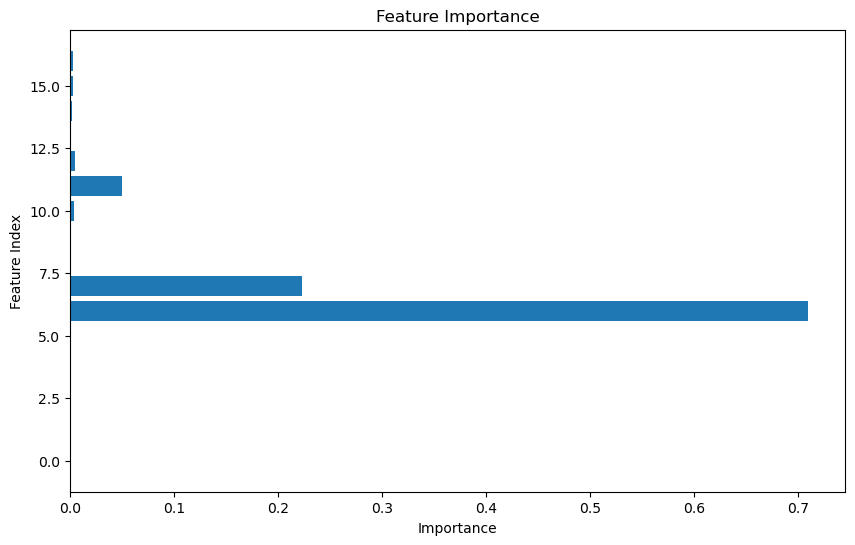

In [105]:
model = pipeline.named_steps['model']
importances = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(range(len(importances)), importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature Index")
plt.show()

In [106]:
error_df = X_test.copy()
error_df['actual'] = y_test
error_df['predicted'] = y_pred
error_df['error'] = abs(y_test - y_pred)

error_df.sort_values(by='error', ascending=False).head(10)

,Utility,City/Town,Zip,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Energy Storage System Size (kWac),Number of Projects,Interconnection Year,dc_ac_ratio,storage_ratio,system_age,location_cluster,developer_performance,size_x_age,size_x_storage,actual,predicted,error
192671,National Grid,TONAWANDA,14150,TM MONTANTE SOLAR DEVELOPMENT LLC,NM,114.24,96.00,7.6,1,2012,1.190000,0.079167,14,7,59965.266667,1344.00,729.600,134099,96819.195312,37279.804688
189958,National Grid,NEDROW,13120,Alternative Power Solutions,NM,118.88,99.90,7.6,1,2016,1.189990,0.076076,10,3,15734.772222,999.00,759.240,139547,103224.093750,36322.906250
138540,Con Ed,BROOKLYN,11211,Other,NM,113.05,95.00,7.6,1,2010,1.190000,0.080000,16,4,11476.477944,1520.00,722.000,132703,98940.500000,33762.500000
125088,PSEGLI,Farmingdale,11735,Green Logic Energy,NM,113.13,95.07,7.6,1,2014,1.189965,0.079941,12,0,12307.593480,1140.84,722.532,132800,99609.007812,33190.992188
110704,PSEGLI,Southampton,11968,Solar Liberty Energy Systems,NM,116.62,98.00,7.6,1,2016,1.190000,0.077551,10,6,14954.703158,980.00,744.800,136893,103867.343750,33025.656250
191841,National Grid,SYRACUSE,13204,"Solar Liberty Energy Systems, Inc.",NM,107.10,90.00,7.6,1,2013,1.190000,0.084444,13,3,17223.048622,1170.00,684.000,125718,97363.179688,28354.820312
216320,NYSEG,Buffalo,14227,Solar Liberty Energy Systems,NM,62.48,52.50,7.6,1,2013,1.190095,0.144762,13,7,14954.703158,682.50,399.000,73336,100461.898438,27125.898438
191702,National Grid,CAMBRIDGE,12816,Monolith Solar Assoc. LLC,NM,105.67,88.80,7.6,1,2015,1.189977,0.085586,11,3,26723.519355,976.80,674.880,124042,97984.398438,26057.601562
176081,Central Hudson,Poughkeepsie,12601,"Green Building and Material Supply, Inc.",NM,62.97,52.92,7.6,1,2011,1.189909,0.143613,15,5,43806.666667,793.80,402.192,73922,97717.695312,23795.695312
189327,National Grid,MENANDS,12204,"Kasselman Solar, LLC",NM,65.45,55.00,7.6,1,2015,1.190000,0.138182,11,6,10947.966038,605.00,418.000,76828,100236.906250,23408.906250


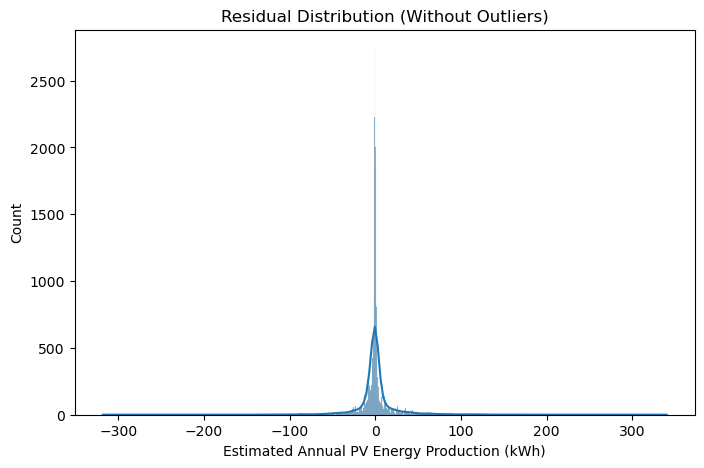

In [110]:
lower = residuals.quantile(0.01)
upper = residuals.quantile(0.99)

filtered_residuals = residuals[(residuals > lower) & (residuals < upper)]

plt.figure(figsize=(8,5))
sns.histplot(filtered_residuals, kde=True)
plt.title("Residual Distribution (Without Outliers)")
plt.show()

In [108]:
abs_errors = abs(y_test - y_pred)

print("Max Error:", abs_errors.max())
print("95% Error:", np.percentile(abs_errors, 95))

Max Error: 37279.8046875
95% Error: 87.91765136718756
